# Tennis Match Predictor

The goal of this project is to analyze different machine learning models for predicting the outcome of a tennis match.

## Contents

1. **Data loading** 
2. **Exploratory data analysis** 
3. **Data cleaning**
4. **Train/test split**
5. **Feature engineering**
6. **Training and evaluation** 

The implementation used in this notebook lives in the `src/` package.

# Setup & Imports

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent 
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import load_data, train_test_split
from src.utils.utils import get_df_from_pipeline
from src.data.preprocess import (
    preprocessing_pipeline, 
    create_labels, 
    DropFeatureSelector
)
from src.features.features import feature_engineering_pipeline
from src.training.training import training_pipeline, fine_tune, feature_selection_pipeline
from src.evaluation.metrics import (
    cross_validation,
    evaluation_metrics,
    feature_importance,
    print_metrics
)
from src.evaluation.plots import (
    plot_confusion_matrix, 
    plot_roc_curve, 
    plot_feature_importance,
    plot_difference
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

import xgboost as xgb

# Data Loading

Loading professional (ATP) tennis single matches played between 2014 and 2025. Datasets are published by [tennis-data.co.uk](http://tennis-data.co.uk/) as one file per season.

`load_data()` concatenate them into a single DataFrame by merging raw files into a single chronologically sorted dataset based on match date

In [2]:
raw_df : pd.DataFrame = load_data()
raw_df.head().transpose()

/Users/chetto/Desktop/Uni/ANNO-III/AI/Project/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/chetto/Desktop/Uni/ANNO-III/AI/Project/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/chetto/Desktop/Uni/ANNO-III/AI/Project/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,0,1,2,3,4
ATP,1,1,1,1,1
Location,Brisbane,Brisbane,Brisbane,Brisbane,Brisbane
Tournament,Brisbane International,Brisbane International,Brisbane International,Brisbane International,Brisbane International
Date,2013-12-30 00:00:00,2013-12-30 00:00:00,2013-12-30 00:00:00,2013-12-30 00:00:00,2013-12-30 00:00:00
Series,ATP250,ATP250,ATP250,ATP250,ATP250
Court,Outdoor,Outdoor,Outdoor,Outdoor,Outdoor
Surface,Hard,Hard,Hard,Hard,Hard
Round,1st Round,1st Round,1st Round,1st Round,1st Round
Best of,3.0,3.0,3.0,3.0,3.0
Winner,Matosevic M.,Nieminen J.,Cilic M.,Querrey S.,Dimitrov G.


# Exploratory Data Analysis

Before proceeding with any data manipulation, we first examine the dataset to gain insights

## Columns

In [3]:
print(raw_df.columns.tolist())

['ATP', 'Location', 'Tournament', 'Date', 'Series', 'Court', 'Surface', 'Round', 'Best of', 'Winner', 'Loser', 'WRank', 'LRank', 'WPts', 'LPts', 'W1', 'L1', 'W2', 'L2', 'W3', 'L3', 'W4', 'L4', 'W5', 'L5', 'Wsets', 'Lsets', 'Comment', 'B365W', 'B365L', 'EXW', 'EXL', 'LBW', 'LBL', 'PSW', 'PSL', 'SJW', 'SJL', 'MaxW', 'MaxL', 'AvgW', 'AvgL', 'BFEW', 'BFEL']


This dataset contains the following information about tennis matches:

- Tournament Information
    - ATP: Tournament number
    - Location: Venue of the tournament
    - Tournament: Name of the tournament
    - Date: Date of the match
    - Series: ATP tournament category
- Match Conditions
    - Court: Court type
    - Surface: Surface type
    - Round: Stage of the tournament
    - Best of: Maximum number of sets played in the match
- Players
    - Winner: Match winner
    - Loser: Match loser
    - WRank: ATP ranking of the winner at tournament start
    - LRank: ATP ranking of the loser at tournament start
    - WPts: ATP ranking points of the winner at tournament start
    - LPts: ATP ranking points of the loser at tournament start
- Match Score
    - W1, L1: Games won by winner/loser in the 1st set
    - W2, L2: Games won by winner/loser in the 2nd set
    - W3, L3: Games won by winner/loser in the 3rd set
    - W4, L4: Games won by winner/loser in the 4th set
    - W5, L5: Games won by winner/loser in the 5th set
    - Wsets: Total sets won by the match winner
    - Lsets: Total sets won by the match loser
    - Comment: Match outcome note
- Bets — odds for the winner (`*W`) and the loser (`*L`) of the match

## Values

As we can see from the output of `info()` function, we need to take care of missing values.

In [4]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30174 entries, 0 to 30173
Data columns (total 44 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   ATP         30174 non-null  int64         
 1   Location    30174 non-null  str           
 2   Tournament  30174 non-null  str           
 3   Date        30174 non-null  datetime64[us]
 4   Series      30174 non-null  str           
 5   Court       30174 non-null  str           
 6   Surface     30174 non-null  str           
 7   Round       30174 non-null  str           
 8   Best of     30159 non-null  float64       
 9   Winner      30174 non-null  str           
 10  Loser       30174 non-null  str           
 11  WRank       30163 non-null  float64       
 12  LRank       30114 non-null  float64       
 13  WPts        30164 non-null  float64       
 14  LPts        30114 non-null  float64       
 15  W1          29967 non-null  float64       
 16  L1          29970 non-null  float

In [5]:
missing = raw_df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

BFEL       29523
BFEW       29523
L5         29041
W5         29041
SJL        27676
SJW        27676
W4         27129
L4         27129
LBW        17841
LBL        17838
EXW        17110
EXL        17105
L3         15651
W3         15651
L2           446
W2           445
PSW          238
PSL          238
Lsets        210
Wsets        207
W1           207
L1           204
B365W        115
B365L        111
LPts          60
LRank         60
MaxW          25
MaxL          25
AvgW          25
AvgL          25
Best of       15
WRank         11
WPts          10
dtype: int64


The code checks for rows where one betting-odds value (MaxW/MaxL or AvgW/AvgL) is present while its corresponding value is missing.

The result is empty, meaning there are no partially missing odds pairs in the dataset, therefore
we can safely use an imputer to fill missing odds values with a constant value.

In [6]:
mask = (
    (raw_df["MaxW"].notna() & raw_df["MaxL"].isna()) |
    (raw_df["MaxW"].isna() & raw_df["MaxL"].notna()) |
    (raw_df["AvgW"].notna() & raw_df["AvgL"].isna()) |
    (raw_df["AvgW"].isna() & raw_df["AvgL"].notna()) 
)

print(raw_df[mask])

Empty DataFrame
Columns: [ATP, Location, Tournament, Date, Series, Court, Surface, Round, Best of, Winner, Loser, WRank, LRank, WPts, LPts, W1, L1, W2, L2, W3, L3, W4, L4, W5, L5, Wsets, Lsets, Comment, B365W, B365L, EXW, EXL, LBW, LBL, PSW, PSL, SJW, SJL, MaxW, MaxL, AvgW, AvgL, BFEW, BFEL]
Index: []

[0 rows x 44 columns]


## Values Distributions

By looking at match statistics using the `describe()` function, we can gain some insights about the values in the dataset:
- Match Format:
    - Most matches are best of 3 sets, this also explains the high amount of null values in the `W4`, `L4`, `W5`, `L5` columns
- Rank/Points:
    - Matches in the dataset are mostly played by top 100 players, since they tipically play more matches in a tournament
    - The median of WRank and LRank indicates that winners are generally better ranked than losers. This statement is valid also for the points.
- Sets/Games:
    - Winning the first set is a strong predictor of winning the match, as the distribution of `W1` shows.
    - Over 50% of best of 3 matches don't go beyond 2 sets

In [7]:
raw_df.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
ATP,30174.0,32.119441,1.0,18.0,32.0,48.0,68.0,17.969127
Date,30174,2019-12-02 12:58:21.928813,2013-12-30 00:00:00,2016-10-04 00:00:00,2019-08-12 00:00:00,2023-02-28 00:00:00,2025-11-16 00:00:00,NaN
Best of,30159.0,3.395106,3.0,3.0,3.0,3.0,5.0,0.796319
WRank,30163.0,58.977191,1.0,17.0,42.0,77.0,1821.0,72.151463
LRank,30114.0,89.286445,1.0,34.0,63.0,101.0,4915.0,121.748755
WPts,30164.0,1949.914368,1.0,726.0,1096.0,2158.0,16950.0,2252.751313
LPts,30114.0,1190.656007,1.0,585.0,842.5,1285.0,16950.0,1268.017428
W1,29967.0,5.806187,0.0,6.0,6.0,6.0,7.0,1.235938
L1,29970.0,4.168769,0.0,3.0,4.0,6.0,8.0,1.816394
W2,29729.0,5.783107,0.0,6.0,6.0,6.0,7.0,1.252386


Insights can be visualized with the following histograms

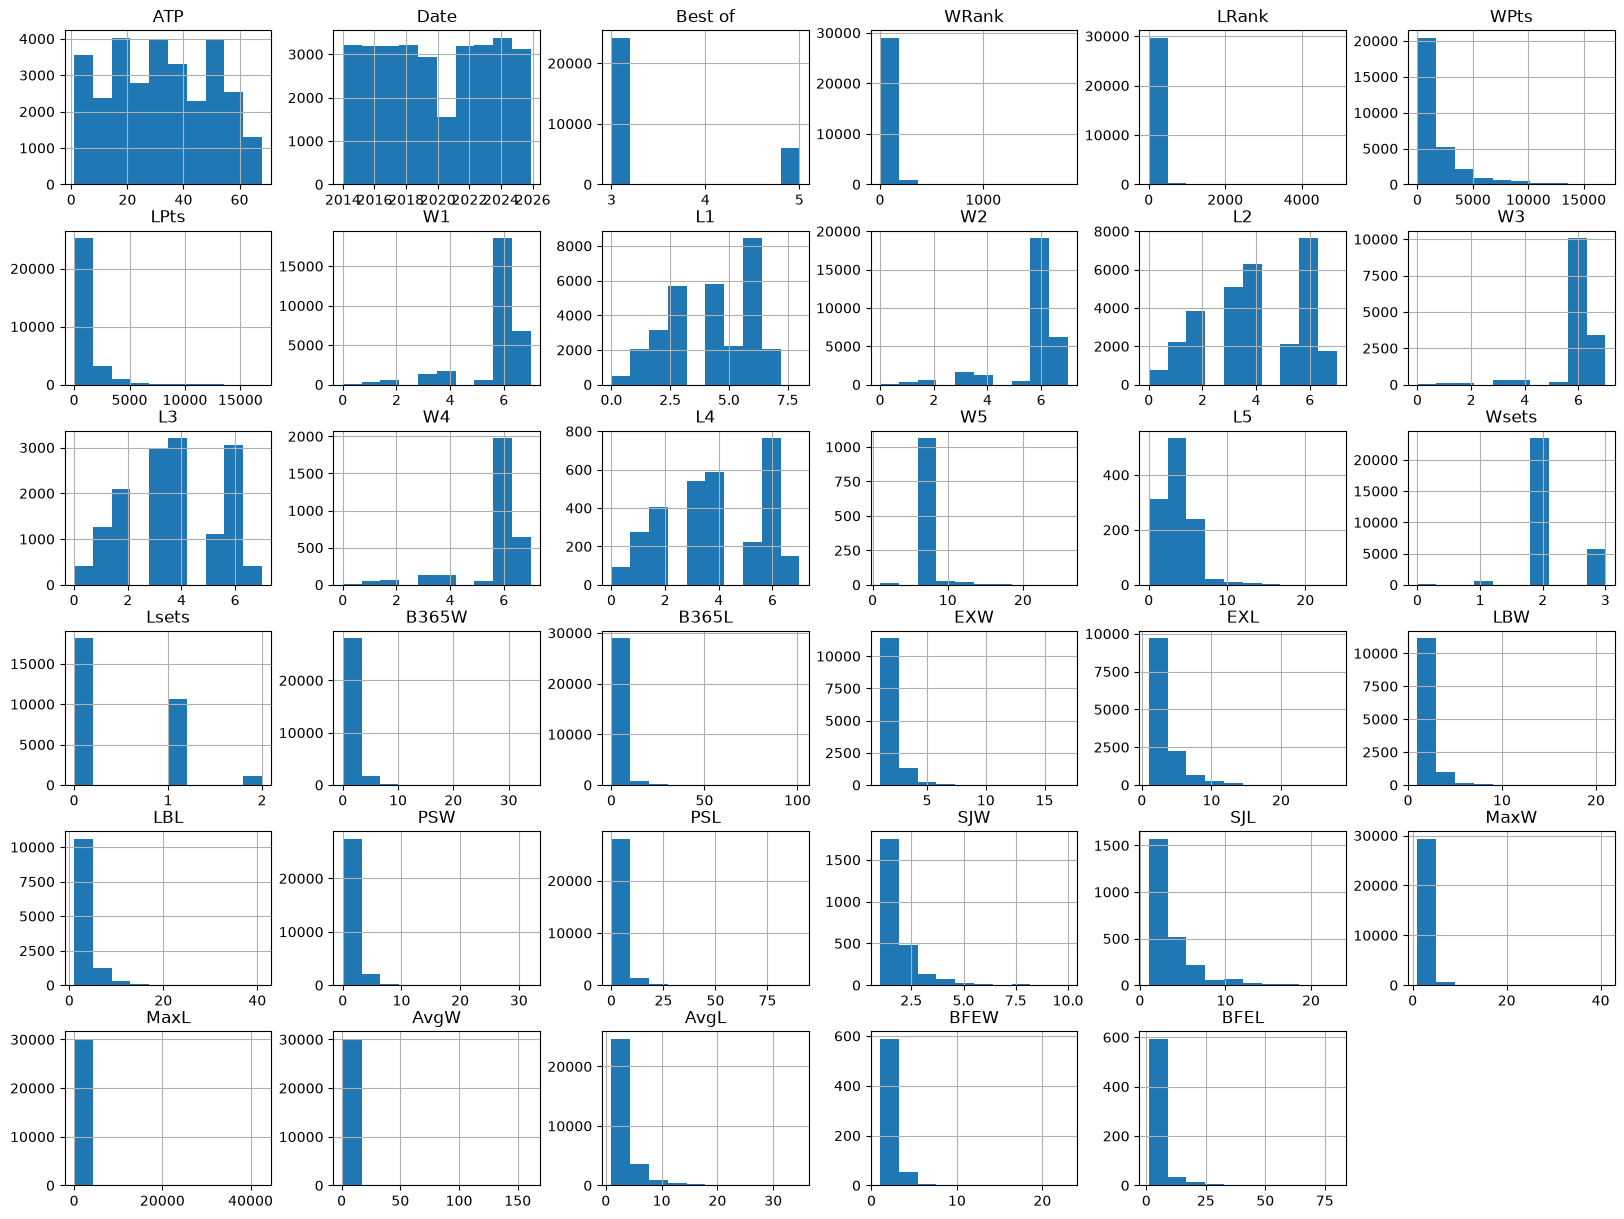

In [8]:
raw_df.hist(figsize=(20, 15));

In [9]:
# print(len(df[df["WRank"] > 1000]))
# print(len(df[df["LRank"] > 1000]))
# print(df[df["WRank"] > 1000][["Winner", "WRank", "Loser", "LRank"]])
# print(df[df["LRank"] > 1000][["Winner", "WRank", "Loser", "LRank"]])

Density of matches indicates that most matches are played by top ranked players

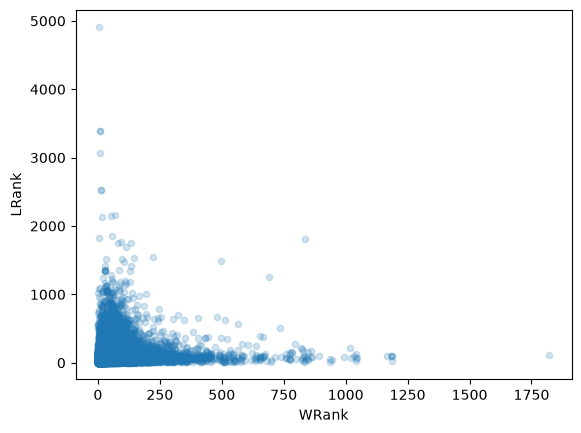

In [10]:
raw_df.plot(kind="scatter", x="WRank", y="LRank", alpha=0.2);

### Winner - Loser Ranking plot

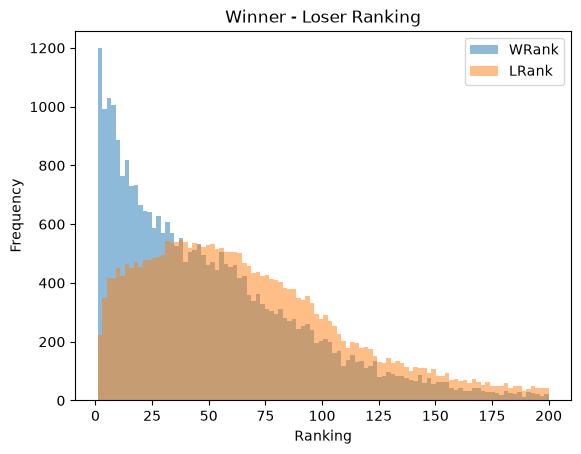

In [11]:
plt.hist(raw_df["WRank"], bins=100, range=(1, 200), alpha=0.5, label='WRank')
plt.hist(raw_df["LRank"], bins=100, range=(1, 200), alpha=0.5, label='LRank')

plt.xlabel('Ranking')
plt.ylabel('Frequency')
plt.title('Winner - Loser Ranking')
plt.legend()

plt.show()

Higher ranking means more matches and more wins

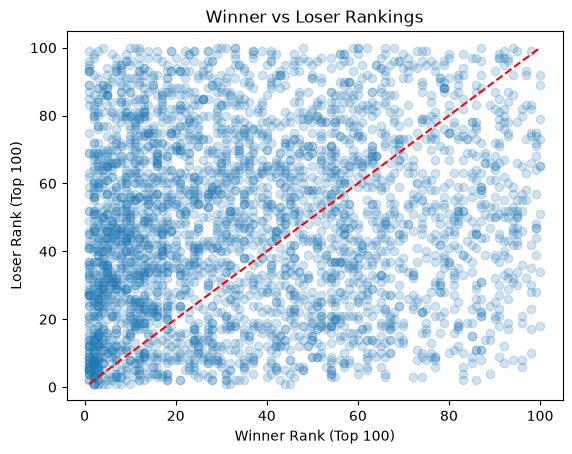

In [12]:
top_100 = raw_df[(raw_df["Date"] >= "2024-01-01") &(raw_df["WRank"] <= 100) & (raw_df["LRank"] <= 100)]
rank_diff = top_100["WRank"] - top_100["LRank"]

plt.scatter(top_100["WRank"], top_100["LRank"], alpha=0.2)
plt.plot([1, 100], [1, 100], color='red', linestyle='--')
plt.xlabel("Winner Rank (Top 100)")
plt.ylabel("Loser Rank (Top 100)")
plt.title("Winner vs Loser Rankings")

plt.show()

Here, we can see that the difference in ranking is more significant among higher-ranked players. Therefore, the same 20-position difference has a greater impact between players ranked 1st and 20th than between players ranked 80th and 100th.

## Values Range

### Comment

In [13]:
raw_df["Comment"].value_counts(dropna=False)

Comment
Completed       29091
Retired           880
Walkover          195
Awarded             5
Sched               1
Disqualified        1
Rrtired             1
Name: count, dtype: int64

The `Comment` column records how a match ended, these are the values that can appear:

- **Completed** — the match was played to its natural end, one player won the required number of sets on court. It's the only outcome whose score and statistics are fully reliable.
- **Retired** — the match started but a player withdrew while it was in progress (injury, illness). The winner is decided by the retirement, not by the score, so games and sets recorded are only the portion played before the withdrawal.
- **Walkover** — a player withdrew *before* the first point, so the match was never played: there is no score and the result carries no information about the two players.
- **Awarded** — the win was assigned by the officials after a mid-match default.
- **Disqualified** — same situation as *Awarded*, recorded under a different label by the data provider.
- **Sched** - the match was scheduled but never played, so there is no score and the result carries no information about the two players.
- **Rrtired** — a typo of *Retired* in the source file, normalized back to *Retired* during preprocessing

Therefore the matches which outcome was Walkover, Awarded, Sched or Disqualified do not provide any information about the match itself and since they are very few, we can drop them in the preprocessing step. 

### Surface

In [14]:
raw_df["Surface"].value_counts(dropna=False)

Surface
Hard     17424
Clay      9276
Grass     3474
Name: count, dtype: int64

### Round

In [15]:
raw_df["Round"].value_counts(dropna=False)

Round
1st Round        13433
2nd Round         8648
Quarterfinals     2940
3rd Round         2128
Semifinals        1494
The Final          747
4th Round          640
Round Robin        144
Name: count, dtype: int64

### Court

In [16]:
raw_df["Court"].value_counts(dropna=False)

Court
Outdoor    25018
Indoor      5156
Name: count, dtype: int64

### Series

In [17]:
raw_df["Series"].value_counts(dropna=False)

Series
ATP250          12408
Masters 1000     6763
Grand Slam       5969
ATP500           4854
Masters Cup       180
Name: count, dtype: int64

### Tournament

In [18]:
raw_df["Tournament"].value_counts(dropna=False)

Tournament
Australian Open                       1524
French Open                           1524
US Open                               1524
Wimbledon                             1397
BNP Paribas Open                      1045
                                      ... 
Napoli Cup                              27
Srpska Open                             27
Zhuhai Championships                    27
U.S.Men's Clay Court Championships      27
Hellenic Championship                   27
Name: count, Length: 148, dtype: int64

## Data Cleaning

The raw data is recorded *from the outcome's point of view*: every row has a `Winner` and a `Loser`, and every statistic of the match comes as a winner/loser pair (`WRank`/`LRank`, `WPts`/`LPts`, `MaxW`/`MaxL`, ...). Therefore the answer is encoded in the column layout itself, and a model trained on it as-is would simply learn "the first player always wins".

To solve the problem, in the function `create_lables()` each match is re-encoded around two general players, `player1` and `player2`, assigned with a fair coin flip. Every winner/loser column pair is swapped consistently based on the coin flip, and the target becomes

$$\texttt{winner} = \begin{cases} 1 & \text{if player1 won the match} \\ 0 & \text{otherwise} \end{cases}$$

In [19]:
cleaned_df = raw_df.copy()
create_labels(cleaned_df)
cleaned_df["winner"].value_counts(dropna=False)

winner
0    15167
1    15007
Name: count, dtype: int64

## Train Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(cleaned_df)
years = X_train["Date"].dt.year.max() - X_train["Date"].dt.year.min() + 1

`train_test_split` (in `src/data/loader.py`) is performed with a 80/20 ratio based on the match date for avoiding data leakage

## Preprocessing

In [21]:
cleaned_X_train, cleaned_y_train = X_train.copy(), y_train.copy()
prep_pipeline = preprocessing_pipeline(X=cleaned_X_train, y=cleaned_y_train)
cleaned_X_train = get_df_from_pipeline(prep_pipeline, cleaned_X_train)

`preprocessing_pipeline` builds the scikit-learn `Pipeline` that turns the raw DataFrame into a cleaned one.

### Row filtering (before the pipeline)

Some rows are removed in place from `X`/`y` *before* the pipeline is assembled if they satisfy one of these conditions:

- **Comment** (`Comment == "Awarded" or Comment == "Walkover" or Comment == "Disqualified" or Comment == "Sched"`), matches that were partially played and whose "result" says nothing about the two players, as we said above these are very few and can be dropped without losing much information.
- **matches with no set count** (`player1_sets`/`player2_sets` missing), rows too incomplete to update player history reliably.

### The pipeline steps

**1. `drop_cols` — `DropFeatureSelector`.** Drops bet columns with high rate of missing values

**2. `preprocessing` — `ColumnTransformer`.** Imputation and encoding, applied per column block:

| block | columns | what it does |
| --- | --- | --- |
| `zero_imputer` | games + sets | fills with `0`, a missing game score means the set was simply never played (most matches are best of 3) |
| `bet_imputer` | the odds columns | fills with `2.0`, equal odd for both players |
| `rank_imputer` | `player1_Rank`, `player2_Rank` | fills with the worst rank observed in the training frame |
| `point_imputer` | `player1_Pts`, `player2_Pts` | fills with the smallest points observed | 
| `categorical_encoder` | `Tournament` | one-hot encoding |
| `round_encoder` | `Round` | ordinal encoding along the real tournament with order: Round Robin → 1st Round → ... → The Final |
| `series_encoder` | `Series` | ordinal encoding along the tournament importance with order: ATP250 → ATP500 → Masters 1000 → Masters Cup → Grand Slam |

**3. `best_of_imputer` — `BestOfImputer`.** `Best of` is missing on part of the dataset, but it is recoverable verifying the sets played

As we can see from the output of `info()` function all columns contain no missing values

In [22]:
cleaned_X_train.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
Index: 23968 entries, 0 to 24138
Data columns (total 174 columns):
 #    Column                                                   Non-Null Count  Dtype         
---   ------                                                   --------------  -----         
 0    player1_1                                                23968 non-null  float64       
 1    player2_1                                                23968 non-null  float64       
 2    player1_2                                                23968 non-null  float64       
 3    player2_2                                                23968 non-null  float64       
 4    player1_3                                                23968 non-null  float64       
 5    player2_3                                                23968 non-null  float64       
 6    player1_4                                                23968 non-null  float64       
 7    player2_4                                             

In [23]:
print(cleaned_X_train.isnull().any(axis=1).sum())

0


The `Comment` column records have been successfully corrected

In [24]:
X_train["Comment"].value_counts()

Comment
Completed       23303
Retired           679
Walkover          151
Awarded             3
Sched               1
Disqualified        1
Rrtired             1
Name: count, dtype: int64

In [25]:
cleaned_X_train["Comment"].value_counts()

Comment
Completed    23303
Retired        665
Name: count, dtype: int64

## Feature Engineering

In [26]:
feat_X_train, feat_y_train = cleaned_X_train.copy(), cleaned_y_train.copy()
feat_pipeline = feature_engineering_pipeline()
feat_X_train = get_df_from_pipeline(feat_pipeline, feat_X_train)

`feature_engineering_pipeline` builds a `Pipeline` with a single step, `FeatureEngineringTransformer`, that replaces the per-match statistics with features describing the two players as they arrive at the match.

The transformer iterate through the matches in chronological order and keeps a `Player` object per athlete (`src/utils/player.py`) and build the following features for each match:

| feature | definition |
| --- | --- |
| `rank_diff` | ATP rank difference at match time |
| `h2h_diff` | head-to-head difference, matches won by `player1` against `player2` minus the opposite |
| `h2h_weighted_diff` | weighted head-to-head difference giving more importance to recent meetings |
| `h2h_court_diff` | head-to-head difference specifically on the same court type |
| `h2h_surface_diff` | head-to-head difference specifically on the same surface |
| `sets_h2h_diff` | same difference counted in sets won in their previous meetings |
| `win_rate_diff` | career win rate observed so far (`wins / matches`, `0.5` for a player with no history) |
| `win_rate_bestof3_diff` | win rate difference in best-of-3 format matches |
| `win_rate_bestof5_diff` | win rate difference in best-of-5 format matches |
| `last_k_matches_win_rate_diff` | win rate over the last `k = 20` matches (`0.5` if no history) defining the recent form |
| `last_k_sets_win_rate_diff` | Win rate over the last `k = 20` matches' sets, indicating set-level form |
| `last_k_matches_rank_variation_diff` | difference in rank variation over the last k matches, indicating trend in performance |
| `win_streak_diff` | consecutive wins currently held by each player |
| `lose_streak_diff` | consecutive losses currently held by each player |
| `surface_win_rate_diff` | win rate on the surface of the match (`0.5` if never played on it). |
| `court_win_rate_diff` | win rate on the court type of the match (`0.5` if never played on it). |
| `fatigue_diff` | difference of a fatigue score built from the previous match. |
| `number_recent_matches_diff` | difference in the number of matches played in a recent time window. |
| `max_bet_diff` | best odds offered across bookmakers |
| `avg_bet_diff` | average odds across bookmakers |
| `weighted_ranking_diff` | Weighted ranking difference accounting for ranking points |


### Columns carried over

Three columns are carried over from the preprocessing step:

- `round` and `series`, the ordinal encodings of the tournament stage and of the tournament importance, they describe the *context* of the match rather than the players.
- the `Tournament_*` one-hot columns

Everything else, the per-set games, the sets, the points, the raw odds and the player names, is consumed to build the features and the player histories and does not reach the model.

In [27]:
feat_X_train.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 23968 entries, 0 to 23967
Data columns (total 162 columns):
 #    Column                                                   Non-Null Count  Dtype  
---   ------                                                   --------------  -----  
 0    Tournament_ABN AMRO World Tennis Tournament              23968 non-null  float64
 1    Tournament_AEGON Championships                           23968 non-null  float64
 2    Tournament_AEGON International                           23968 non-null  float64
 3    Tournament_AEGON Open                                    23968 non-null  float64
 4    Tournament_ASB Classic                                   23968 non-null  float64
 5    Tournament_ATP Vegeta Croatia Open                       23968 non-null  float64
 6    Tournament_Abierto Mexicano                              23968 non-null  float64
 7    Tournament_Abierto Mexicano Mifel                        23968 non-null  float64
 8    Tournament_Adelaide Inter